# 实验05：禁止循环 —— 使用向量化构建回测器

## Part 1：设置（市场生成器）

这一格是整个实验的准备工作。

我们会使用：
- `pandas`：处理表格数据（DataFrame）
- `numpy`：生成随机数、做数值计算
- `matplotlib.pyplot`：画收益曲线
- `time`：用于计时（虽然本实验主要使用 `%%time`）

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time



## 2：生成模拟市场数据

这一步是本实验的“数据来源”。

因为我们不一定有真实的高频交易数据，所以先用程序生成一份“模拟市场”：
- `timestamp`：每一分钟一个时间点
- `price`：价格从100开始，按随机游走方式波动
- `volume`：每分钟成交量，随机生成

这里我们生成 **100万行** 数据，是为了让大家真正感受到：
- 循环方法会非常慢
- 向量化方法会非常快。

In [2]:
# Fix random seed for reproducibility
np.random.seed(42)

# Generate 1,000,000 rows of minute-level market data
rows = 1_000_000

print(f"Market open... generating {rows:,} rows.")

# Synthetic market:
# timestamp: one row per minute
# price: random walk starting from 100
# volume: random integer volume per minute
df = pd.DataFrame({
    'timestamp': pd.date_range(start='2020-01-01', periods=rows, freq='min'),
    'price': 100 + np.cumsum(np.random.normal(0, 1, rows)),
    'volume': np.random.randint(100, 10000, rows)
})

print("Market generated.")
print("Last price:", df['price'].iloc[-1])

# Preview
df.head()



Market open... generating 1,000,000 rows.
Market generated.
Last price: -1499.756454256387


,timestamp,price,volume
0,2020-01-01 00:00:00,100.496714,8048
1,2020-01-01 00:01:00,100.358450,1428
2,2020-01-01 00:02:00,101.006138,204
3,2020-01-01 00:03:00,102.529168,4116
4,2020-01-01 00:04:00,102.295015,1684


## 3：检查数据结构

生成完数据后，不能立刻开始建策略。我们应该先检查：

- 一共有多少行？
- 每列的数据类型是什么？
- 有没有空值？
- 内存占用大概是多少？

`df.info()` 是做这件事最常用的工具之一。。

In [3]:
# Check table schema, row count, and dtypes
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   timestamp  1000000 non-null  datetime64[ns]
 1   price      1000000 non-null  float64       
 2   volume     1000000 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1)
memory usage: 19.1 MB


## Part 2：羞耻循环（对照组）

这一格故意使用“坏方法”。

我们要生成一个非常简单的交易信号：
- 如果当前价格 > 上一分钟价格，则记为 `BUY`，用 1 表示
- 否则记为 `SELL`，用 0 表示

这里我们用 `for` 循环逐行判断，目的是让大家看到：
- 逻辑虽然正确
- 但在大数据规模下，这种写法非常慢

课堂重点：
- 这段代码能帮助学生理解“我们到底在算什么”
- 但后面会用向量化重写，展示真正正确的 Pandas 思维

In [4]:
%%time

# -------------------------------------------------
# Baseline loop version (control group)
# Rule: if current price > previous minute price -> BUY(1), else SELL(0)
# -------------------------------------------------

signals = []

# Start from index 1 because index 0 has no previous row
for i in range(1, len(df)):
    current_price = df['price'].iloc[i]
    prev_price = df['price'].iloc[i - 1]

    if current_price > prev_price:
        signals.append(1)
    else:
        signals.append(0)

# First row has no previous price
signals.insert(0, 0)

df['signal_loop'] = signals

print("Loop signal generation complete.")
df[['timestamp', 'price', 'signal_loop']].head()



Loop signal generation complete.
CPU times: total: 3.17 s
Wall time: 8.81 s


,timestamp,price,signal_loop
0,2020-01-01 00:00:00,100.496714,0
1,2020-01-01 00:01:00,100.358450,0
2,2020-01-01 00:02:00,101.006138,1
3,2020-01-01 00:03:00,102.529168,1
4,2020-01-01 00:04:00,102.295015,0


## Part 3：向量化之神（Pandas速度）

现在我们做和上一格完全相同的事情，但不用 `for` 循环。

核心思想：
1. 把整列 `price` 向下移动一格，得到上一分钟价格
2. 用整列和整列比较：`price > prev_price`
3. 把 True/False 转成 1/0

这就是 Pandas 的列式思维：
- 不是“逐行算”
- 而是“整列一起算”

In [5]:
%%time

# -------------------------------------------------
# Vectorized version (no loops)
# 1) Shift price by 1 row to get previous price
# 2) Compare full columns at once
# 3) Convert True/False to 1/0
# -------------------------------------------------

df['prev_price'] = df['price'].shift(1)
df['signal_vector'] = (df['price'] > df['prev_price']).astype(int)

print("Vectorized signal generation complete.")
df[['timestamp', 'price', 'prev_price', 'signal_vector']].head()



Vectorized signal generation complete.
CPU times: total: 0 ns
Wall time: 25.4 ms


,timestamp,price,prev_price,signal_vector
0,2020-01-01 00:00:00,100.496714,NaN,0
1,2020-01-01 00:01:00,100.358450,100.496714,0
2,2020-01-01 00:02:00,101.006138,100.358450,1
3,2020-01-01 00:03:00,102.529168,101.006138,1
4,2020-01-01 00:04:00,102.295015,102.529168,0


## 6：验证循环版与向量化版是否一致

向量化更快，不代表它一定写对了。

科学计算里一个重要习惯是：
- 新方法写出来之后，要和“朴素方法”比对结果

这里我们检查：
- `signal_loop`
- `signal_vector`

是否完全一致。

In [6]:
# 第一行由于没有前一分钟价格，循环版是0
# 向量化版第一行比较结果通常也是False -> 0
# 我们检查两列是否完全一致

same_result = (df['signal_loop'] == df['signal_vector']).all()
print("循环版和向量化版结果是否一致：", same_result)

循环版和向量化版结果是否一致： True


## Part 4：策略回测与收益计算

现在我们已经有了交易信号，下一步是计算“如果持有股票，每分钟能赚多少/亏多少”。

Pandas 提供了一个非常方便的方法：`pct_change()`。

它的含义是：
- 当前价格相对于上一行价格的百分比变化

例如：
- 从100涨到101，收益率就是 1%
- 从100跌到99，收益率就是 -1%

In [7]:
# Percent change from previous row
df['pct_change'] = df['price'].pct_change()

# Preview
df[['timestamp', 'price', 'pct_change']].head()



,timestamp,price,pct_change
0,2020-01-01 00:00:00,100.496714,NaN
1,2020-01-01 00:01:00,100.358450,-0.001376
2,2020-01-01 00:02:00,101.006138,0.006454
3,2020-01-01 00:03:00,102.529168,0.015079
4,2020-01-01 00:04:00,102.295015,-0.002284


## 8：信号必须滞后1格（避免未来函数）

这是整个回测实验最重要的概念之一。

如果我们用“当前分钟价格上涨”来决定“当前分钟是否持仓”，那就是作弊。
因为你在做决策时，其实还不知道这一分钟的涨跌已经发生。

正确做法是：
- 用上一分钟生成的信号
- 去决定下一分钟是否持仓

所以我们要把交易信号整体向下移动1格。

In [8]:
# Shift signal by 1 row to avoid look-ahead bias
df['signal_shifted'] = df['signal_vector'].shift(1)

# Fill first NaN with 0 (no position at start)
df['signal_shifted'] = df['signal_shifted'].fillna(0)

df[['timestamp', 'signal_vector', 'signal_shifted']].head()



,timestamp,signal_vector,signal_shifted
0,2020-01-01 00:00:00,0,0.0
1,2020-01-01 00:01:00,0,0.0
2,2020-01-01 00:02:00,1,0.0
3,2020-01-01 00:03:00,1,1.0
4,2020-01-01 00:04:00,0,1.0


## 9：根据仓位计算策略收益

现在我们有两样东西：
- 每分钟价格变化率 `pct_change`
- 每分钟是否持仓 `signal_shifted`

回测逻辑非常简单：
- 如果仓位是 1（持有股票），那么这一分钟收益 = 市场收益率
- 如果仓位是 0（持有现金），那么这一分钟收益 = 0

因此：
`strategy_return = signal_shifted * pct_change`

In [9]:
# Vectorized ROI rule from assignment
# strategy_return = signal_shifted * pct_change
df['strategy_return'] = df['signal_shifted'] * df['pct_change']

# Preview
df[['timestamp', 'pct_change', 'signal_shifted', 'strategy_return']].head(10)



,timestamp,pct_change,signal_shifted,strategy_return
0,2020-01-01 00:00:00,NaN,0.0,NaN
1,2020-01-01 00:01:00,-0.001376,0.0,-0.000000
2,2020-01-01 00:02:00,0.006454,0.0,0.000000
3,2020-01-01 00:03:00,0.015079,1.0,0.015079
4,2020-01-01 00:04:00,-0.002284,1.0,-0.002284
5,2020-01-01 00:05:00,-0.002289,0.0,-0.000000
6,2020-01-01 00:06:00,0.015473,0.0,0.000000
7,2020-01-01 00:07:00,0.007405,1.0,0.007405
8,2020-01-01 00:08:00,-0.004497,1.0,-0.004497
9,2020-01-01 00:09:00,0.005220,0.0,0.000000


## 10：把每分钟收益累积成净值曲线

单独看某一分钟赚多少没有意义。
我们真正关心的是：

- 如果一开始投入100元
- 随着时间推移
- 最后这100元会变成多少

因此我们要把每一分钟收益“连乘起来”，形成累计收益曲线。

这里我们同时计算两条曲线：
1. 买入持有（一直持有股票）
2. 策略收益（按照信号决定是否持仓）

In [10]:
# Buy and Hold curve (start capital = 100)
df['buy_and_hold_curve'] = (1 + df['pct_change'].fillna(0)).cumprod() * 100

# Strategy curve (start capital = 100)
df['strategy_curve'] = (1 + df['strategy_return'].fillna(0)).cumprod() * 100

df[['timestamp', 'buy_and_hold_curve', 'strategy_curve']].head()



,timestamp,buy_and_hold_curve,strategy_curve
0,2020-01-01 00:00:00,100.000000,100.000000
1,2020-01-01 00:01:00,99.862419,100.000000
2,2020-01-01 00:02:00,100.506906,100.000000
3,2020-01-01 00:03:00,102.022409,101.507859
4,2020-01-01 00:04:00,101.789412,101.276038


## 11：绘制表现对比图

实验要求中明确指出，必须画出：
- 买入持有（Buy and Hold）
- 你的策略（Strategy）

把两条曲线画在同一张图上，可以直观看出：
- 策略是否跑赢市场
- 策略波动是否更小
- 回测逻辑是否大致合理

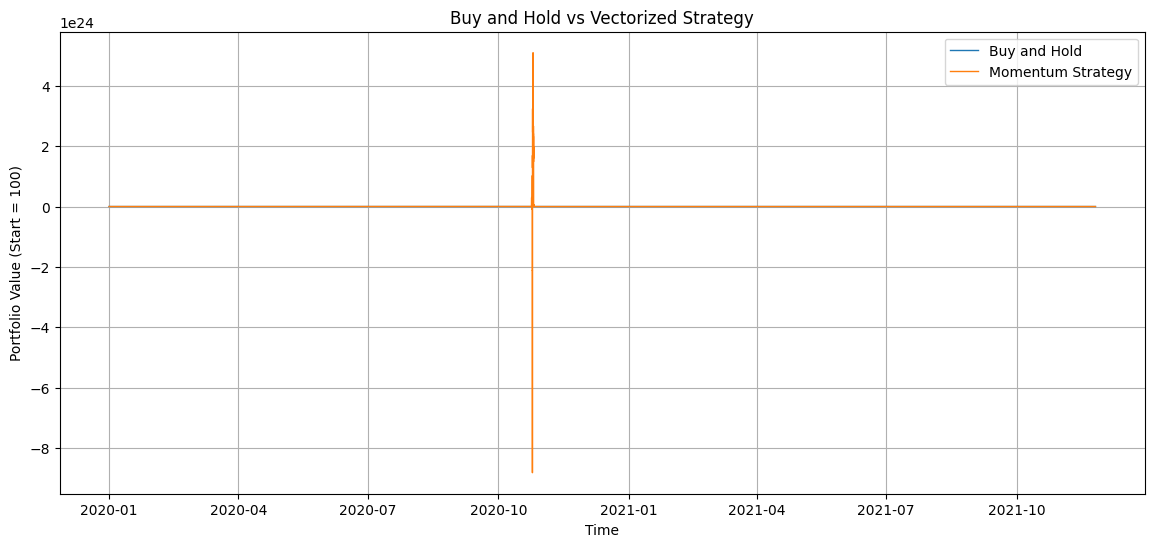

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(df['timestamp'], df['buy_and_hold_curve'], label='Buy and Hold', linewidth=1)
plt.plot(df['timestamp'], df['strategy_curve'], label='Momentum Strategy', linewidth=1)

plt.title('Buy and Hold vs Vectorized Strategy')
plt.xlabel('Time')
plt.ylabel('Portfolio Value (Start = 100)')
plt.legend()
plt.grid(True)

plt.show()

## 12：输出最终策略结果

画图是直观比较，打印最终净值则是精确比较。

这里我们输出：
- 买入持有最终资产
- 策略最终资产

这样可以快速判断：
- 策略是否跑赢基准
- 回测结果是否大致合理

In [12]:
final_buy_hold = df['buy_and_hold_curve'].iloc[-1]
final_strategy = df['strategy_curve'].iloc[-1]

print(f"Final Buy and Hold value: {final_buy_hold:.2f}")
print(f"Final Strategy value: {final_strategy:.2f}")

if final_strategy > final_buy_hold:
    print("Strategy outperformed the market.")
else:
    print("Strategy did not outperform the market.")



Final Buy and Hold value: -1492.34
Final Strategy value: 11719565532953932.00
Strategy outperformed the market.


## Part 4：更复杂的向量化策略

前面的策略非常简单，只看“当前价格是否高于前一分钟价格”。

现在我们尝试一个更像真实量化策略的规则：

- 计算 50 期移动平均线（SMA_50）
- 如果当前价格 > SMA_50，则买入（1）
- 否则卖出（0）

重点仍然是：
- 不能写循环
- 用 Pandas 的 `rolling()` 做窗口计算
- 用向量化方式完成整个策略管道

In [13]:
%%time

# -------------------------------------------------
# SMA strategy: if price > SMA_50 then BUY else SELL
# -------------------------------------------------

df['SMA_50'] = df['price'].rolling(window=50).mean()
df['signal_sma'] = np.where(df['price'] > df['SMA_50'], 1, 0)

df['signal_sma_shifted'] = df['signal_sma'].shift(1).fillna(0)
df['strategy_return_sma'] = df['signal_sma_shifted'] * df['pct_change']
df['strategy_curve_sma'] = (1 + df['strategy_return_sma'].fillna(0)).cumprod() * 100

df[['timestamp', 'price', 'SMA_50', 'signal_sma', 'strategy_curve_sma']].head(60)



CPU times: total: 62.5 ms
Wall time: 93.9 ms


,timestamp,price,SMA_50,signal_sma,strategy_curve_sma
0,2020-01-01 00:00:00,100.496714,NaN,0,100.0
1,2020-01-01 00:01:00,100.358450,NaN,0,100.0
2,2020-01-01 00:02:00,101.006138,NaN,0,100.0
3,2020-01-01 00:03:00,102.529168,NaN,0,100.0
4,2020-01-01 00:04:00,102.295015,NaN,0,100.0
5,2020-01-01 00:05:00,102.060878,NaN,0,100.0
6,2020-01-01 00:06:00,103.640091,NaN,0,100.0
7,2020-01-01 00:07:00,104.407525,NaN,0,100.0
8,2020-01-01 00:08:00,103.938051,NaN,0,100.0
9,2020-01-01 00:09:00,104.480611,NaN,0,100.0


## 14：比较三种表现

现在我们把三条曲线放在一起比较：

1. 买入持有
2. 简单动量策略（价格 > 前一分钟价格）
3. SMA(50) 策略

这样做的好处是：
- 能看到不同策略的相对表现
- 能理解“策略规则改变后，净值曲线也会改变”
- 能帮助学生建立“基准 vs 策略 vs 另一策略”的比较意识

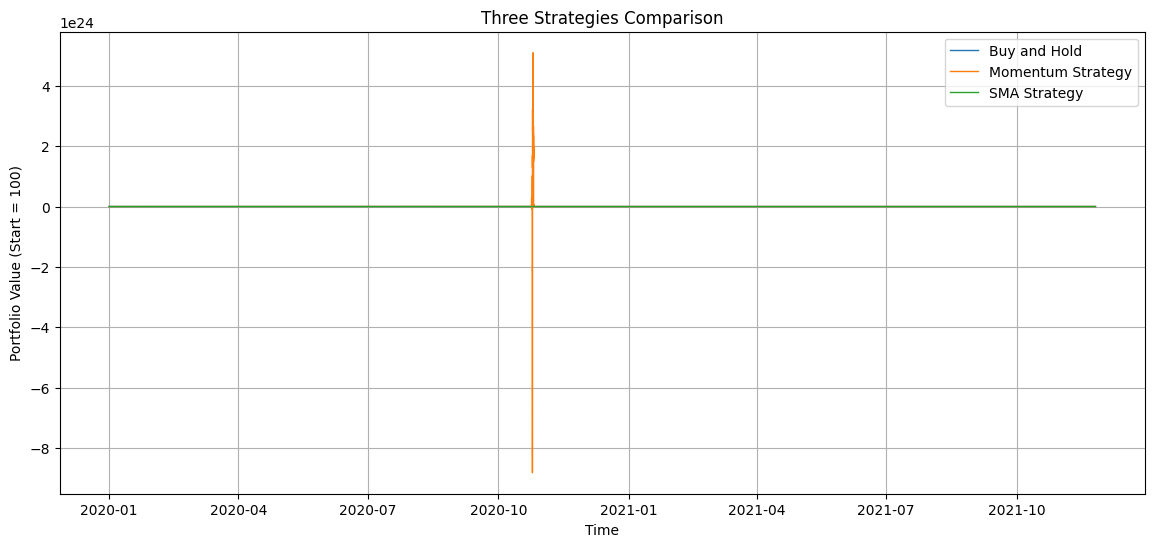

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(df['timestamp'], df['buy_and_hold_curve'], label='Buy and Hold', linewidth=1)
plt.plot(df['timestamp'], df['strategy_curve'], label='Momentum Strategy', linewidth=1)
plt.plot(df['timestamp'], df['strategy_curve_sma'], label='SMA Strategy', linewidth=1)

plt.title('Three Strategies Comparison')
plt.xlabel('Time')
plt.ylabel('Portfolio Value (Start = 100)')
plt.legend()
plt.grid(True)

plt.show()

## Part 5：方法链式

前面的写法非常适合教学，因为每一步都清楚地展开了。

但在真实行业代码中，如果中间变量很多，Notebook 或脚本会越来越乱。
这时候，Pandas 的一种高级写法是“方法链式”：

- 一步接一步地写成流水线
- 用 `.assign()` 创建新列
- 最后得到一个干净的数据处理管道

In [15]:
# Method chaining version of the whole pipeline

df_chain = (
    df[['timestamp', 'price', 'volume']].copy()
    .assign(prev_price=lambda x: x['price'].shift(1))
    .assign(daily_return=lambda x: (x['price'] - x['prev_price']) / x['prev_price'])
    .assign(signal=lambda x: np.where(x['daily_return'] > 0, 1, 0))
    .assign(signal_shifted=lambda x: pd.Series(x['signal']).shift(1).fillna(0))
    .assign(strategy_return=lambda x: x['signal_shifted'] * x['daily_return'])
    .assign(strategy_curve=lambda x: (1 + x['strategy_return'].fillna(0)).cumprod() * 100)
    .dropna()
)

df_chain.head()



,timestamp,price,volume,prev_price,daily_return,signal,signal_shifted,strategy_return,strategy_curve
1,2020-01-01 00:01:00,100.358450,1428,100.496714,-0.001376,0,0.0,-0.000000,100.000000
2,2020-01-01 00:02:00,101.006138,204,100.358450,0.006454,1,0.0,0.000000,100.000000
3,2020-01-01 00:03:00,102.529168,4116,101.006138,0.015079,1,1.0,0.015079,101.507859
4,2020-01-01 00:04:00,102.295015,1684,102.529168,-0.002284,0,1.0,-0.002284,101.276038
5,2020-01-01 00:05:00,102.060878,4497,102.295015,-0.002289,0,0.0,-0.000000,101.276038


## 16：展示方法链式生成的策略曲线

上一格我们用链式写法重建了整个策略管道。
这一格把它画出来，验证：

- 链式代码不只是“写得漂亮”
- 它也能生成正确的策略结果

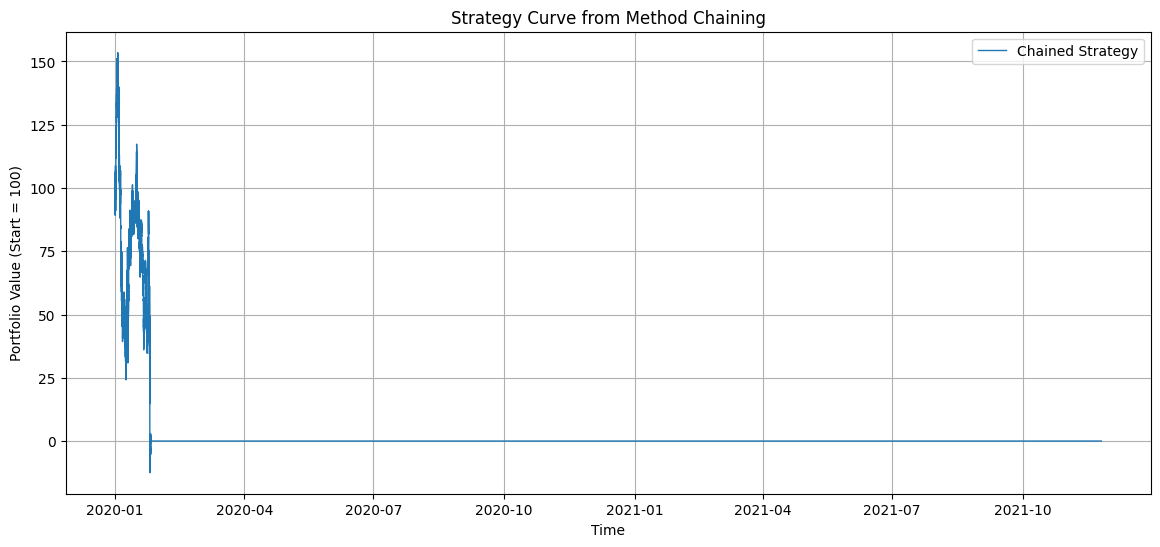

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(df_chain['timestamp'], df_chain['strategy_curve'], label='Chained Strategy', linewidth=1)

plt.title('Strategy Curve from Method Chaining')
plt.xlabel('Time')
plt.ylabel('Portfolio Value (Start = 100)')
plt.legend()
plt.grid(True)

plt.show()